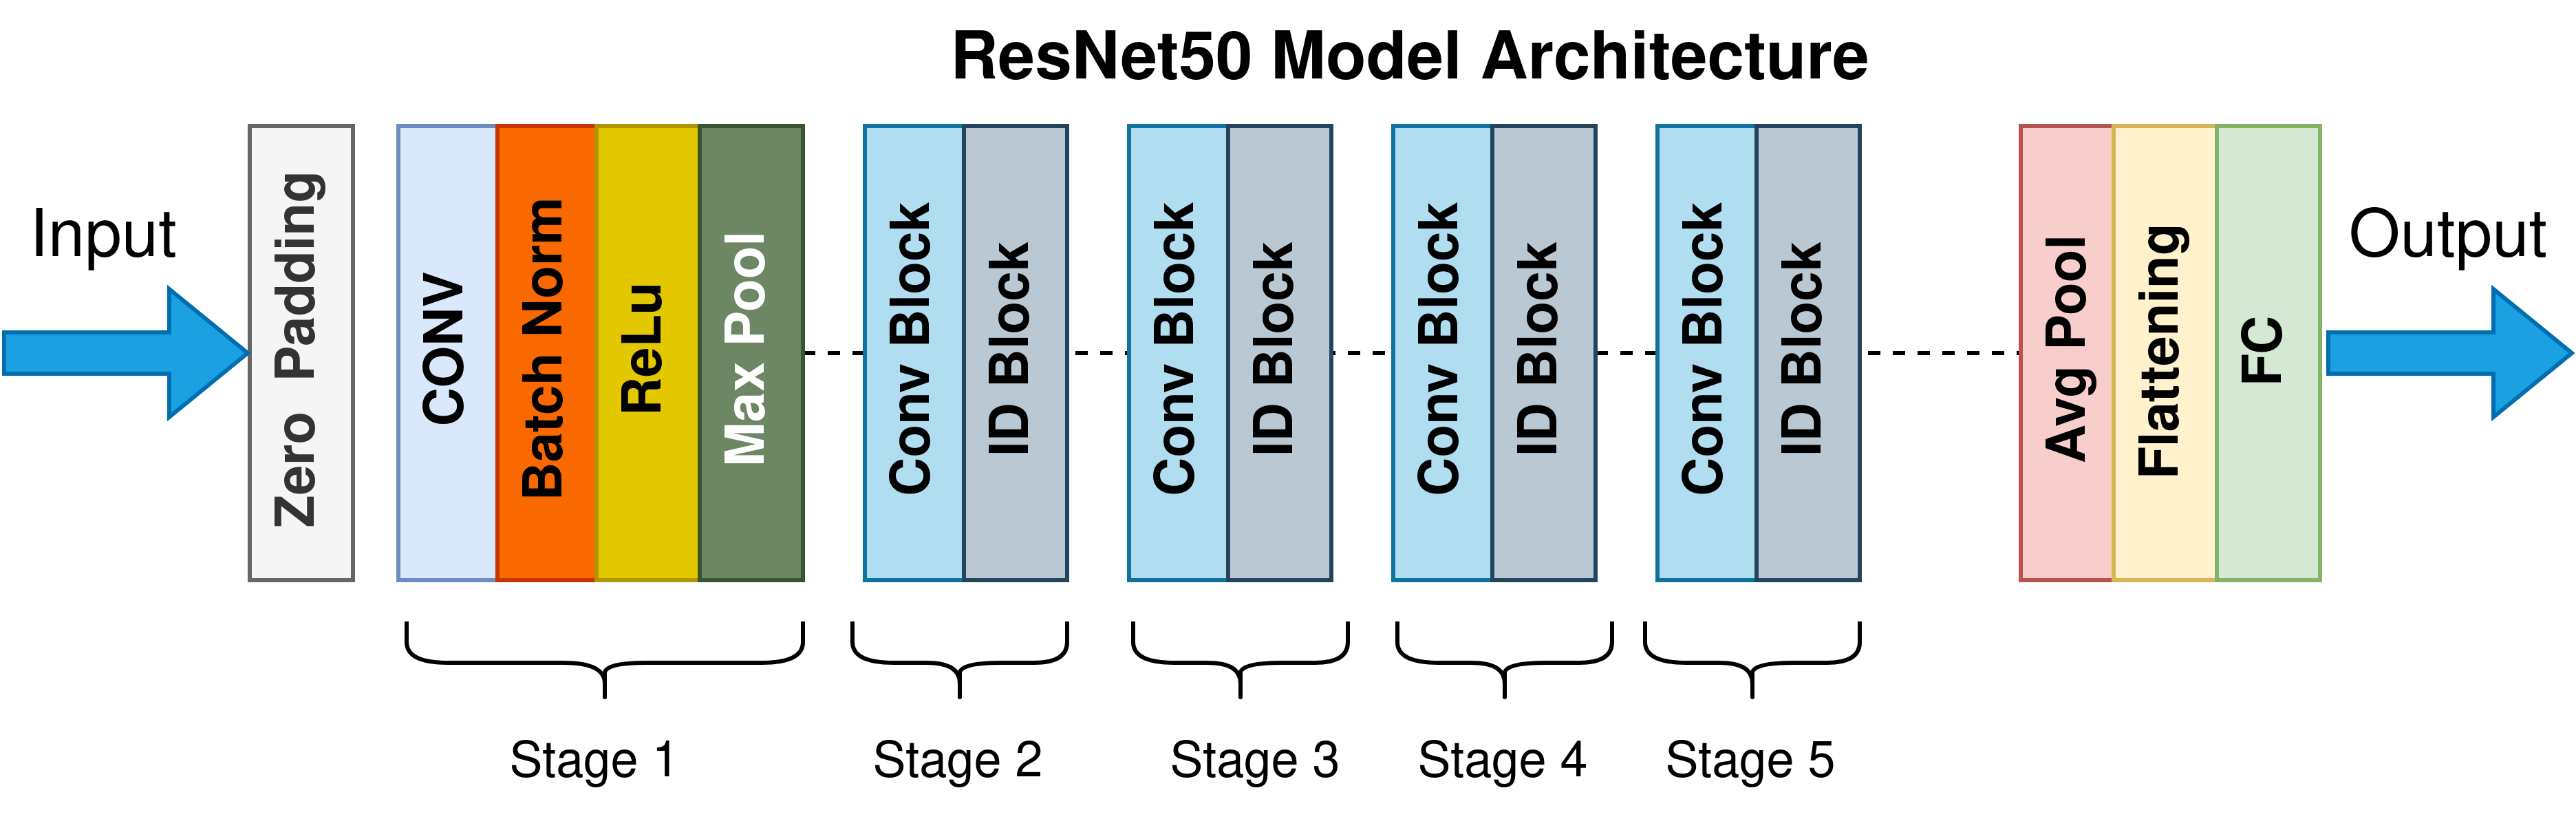

https://github.com/keras-team/keras/blob/v3.3.3/keras/src/applications/resnet.py#L48

In [1]:
import os
import shutil
import itertools
from glob import glob
from pathlib import Path
import json
import platform

In [2]:
import numpy as np
import pandas as pd
import sklearn
import matplotlib.pyplot as plt
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
)

import keras
import tensorflow as tf
from keras.models import Model
from keras.callbacks import EarlyStopping
from keras.utils import image_dataset_from_directory, get_file
from keras.applications.resnet50 import preprocess_input

import kagglehub

In [3]:
SEED = 42
keras.utils.set_random_seed(SEED)
TRAIN_FRACTION = 0.70
VALIDATION_FRACTION = 0.15
TEST_FRACTION = 0.15
DATASET_ID = "andrewmvd/lung-and-colon-cancer-histopathological-images"

print("TensorFlow:", tf.__version__)
print("Keras:", keras.__version__)

TensorFlow: 2.20.0
Keras: 3.13.2


In [4]:
OUTPUT_DIR = Path("/content/exp-3-outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


In [5]:
assert TRAIN_FRACTION + VALIDATION_FRACTION + TEST_FRACTION == 1.0
print({
    "python": platform.python_version(),
    "pandas": pd.__version__,
    "scikit_learn": sklearn.__version__,
})

{'python': '3.12.13', 'pandas': '2.2.2', 'scikit_learn': '1.6.1'}


In [6]:
dataset_root = Path(kagglehub.dataset_download(DATASET_ID))

Using Colab cache for faster access to the 'lung-and-colon-cancer-histopathological-images' dataset.


In [7]:
colon_directories = list(dataset_root.rglob("colon_image_sets"))

if len(colon_directories) != 1:
    raise RuntimeError(
        f"Expected exactly one colon_image_sets directory, found {colon_directories}"
    )

colon_root = colon_directories[0]
print("Dataset root:", dataset_root)
print("Colon root:", colon_root)

Dataset root: /kaggle/input/lung-and-colon-cancer-histopathological-images
Colon root: /kaggle/input/lung-and-colon-cancer-histopathological-images/lung_colon_image_set/colon_image_sets


## 3. Build the binary index

The positive class is adenocarcinoma (`1`); benign tissue is class `0`. Stable relative paths make the manifest portable across Colab runtimes.

In [8]:
CLASS_MAPPING = {
    "colon_n": {"label": 0, "class_name": "benign"},
    "colon_aca": {"label": 1, "class_name": "adenocarcinoma"},
}
SUPPORTED_SUFFIXES = {".jpg", ".jpeg", ".png"}
records = []

for folder_name, class_info in CLASS_MAPPING.items():
    class_directory = colon_root / folder_name
    if not class_directory.is_dir():
        raise FileNotFoundError(f"Missing expected class directory: {class_directory}")

    image_paths = sorted(
        path for path in class_directory.iterdir()
        if path.is_file() and path.suffix.lower() in SUPPORTED_SUFFIXES
    )
    for image_path in image_paths:
        records.append({
            "relative_path": image_path.relative_to(colon_root).as_posix(),
            "filepath": str(image_path),
            "label": class_info["label"],
            "class_name": class_info["class_name"],
        })

image_index = pd.DataFrame.from_records(records).sort_values(
    ["label", "relative_path"]
).reset_index(drop=True)

expected_counts = {"benign": 5000, "adenocarcinoma": 5000}
actual_counts = image_index["class_name"].value_counts().to_dict()
assert actual_counts == expected_counts, (actual_counts, expected_counts)
assert len(image_index) == 10_000
assert image_index["relative_path"].is_unique
display(image_index.head())
display(image_index["class_name"].value_counts().sort_index())


,relative_path,filepath,label,class_name
0,colon_n/colonn1.jpeg,/kaggle/input/lung-and-colon-cancer-histopatho...,0,benign
1,colon_n/colonn10.jpeg,/kaggle/input/lung-and-colon-cancer-histopatho...,0,benign
2,colon_n/colonn100.jpeg,/kaggle/input/lung-and-colon-cancer-histopatho...,0,benign
3,colon_n/colonn1000.jpeg,/kaggle/input/lung-and-colon-cancer-histopatho...,0,benign
4,colon_n/colonn1001.jpeg,/kaggle/input/lung-and-colon-cancer-histopatho...,0,benign


,count
class_name,
adenocarcinoma,5000
benign,5000


## 4. Download and inspect the official LC25000-clean groups

The published table identifies augmented sister images with a shared `group_id`. This cell only downloads and validates the table; it does not change the dataset partition yet.


In [9]:
GROUPS_URL = (
    "https://raw.githubusercontent.com/GeorgeBatch/"
    "LC25000-clean/main/kaggle/lc25000_image_groups.csv"
)
EXPECTED_GROUP_COLUMNS = {
    "stem",
    "filename",
    "label",
    "tissue",
    "local_cluster_label",
    "group_id",
}

image_groups = pd.read_csv(GROUPS_URL)

assert len(image_groups) == 25_000, len(image_groups)
assert set(image_groups.columns) == EXPECTED_GROUP_COLUMNS, image_groups.columns.tolist()
assert image_groups["stem"].is_unique
assert image_groups["group_id"].notna().all()

print("Grouping table shape:", image_groups.shape)
print("Columns:", image_groups.columns.tolist())
print("Unique groups:", image_groups["group_id"].nunique())
display(image_groups["tissue"].value_counts().sort_index())
display(image_groups["label"].value_counts().sort_index())
display(image_groups.head())


Grouping table shape: (25000, 6)
Columns: ['stem', 'filename', 'label', 'tissue', 'local_cluster_label', 'group_id']
Unique groups: 1246


,count
tissue,
colon,10000
lung,15000


,count
label,
colon_aca,5000
colon_n,5000
lung_aca,5000
lung_n,5000
lung_scc,5000


,stem,filename,label,tissue,local_cluster_label,group_id
0,colonca1021,colonca1021.jpeg,colon_aca,colon,0,0
1,colonca1078,colonca1078.jpeg,colon_aca,colon,0,0
2,colonca1139,colonca1139.jpeg,colon_aca,colon,0,0
3,colonca1256,colonca1256.jpeg,colon_aca,colon,0,0
4,colonca1496,colonca1496.jpeg,colon_aca,colon,0,0


## 5. Match every colon image to its published group

Join by the filename stem and require a strict one-to-one match. Training must not begin unless all 10,000 local colon images receive the correct published `group_id`.


In [10]:
OFFICIAL_TO_CLASS_NAME = {
    "colon_n": "benign",
    "colon_aca": "adenocarcinoma",
}

colon_groups = image_groups.loc[
    image_groups["tissue"].eq("colon"),
    ["stem", "filename", "label", "local_cluster_label", "group_id"],
].rename(columns={"label": "official_label"})

assert len(colon_groups) == 10_000
assert colon_groups["stem"].is_unique

grouped_image_index = image_index.copy()
grouped_image_index["stem"] = grouped_image_index["relative_path"].map(
    lambda value: Path(value).stem
)
grouped_image_index = grouped_image_index.merge(
    colon_groups,
    on="stem",
    how="left",
    validate="one_to_one",
    indicator=True,
)

assert len(grouped_image_index) == 10_000
assert grouped_image_index["relative_path"].is_unique
assert grouped_image_index["_merge"].eq("both").all(), (
    grouped_image_index["_merge"].value_counts().to_dict()
)
assert grouped_image_index["group_id"].notna().all()
assert grouped_image_index["official_label"].map(OFFICIAL_TO_CLASS_NAME).equals(
    grouped_image_index["class_name"]
)
grouped_image_index = grouped_image_index.drop(columns="_merge")

print("Matched colon images:", len(grouped_image_index))
print("Unique colon groups:", grouped_image_index["group_id"].nunique())
display(grouped_image_index.groupby("class_name")["group_id"].nunique())
display(grouped_image_index.groupby("class_name")["group_id"].size())
display(grouped_image_index.head())


Matched colon images: 10000
Unique colon groups: 506


,group_id
class_name,
adenocarcinoma,249
benign,257


,group_id
class_name,
adenocarcinoma,5000
benign,5000


,relative_path,filepath,label,class_name,stem,filename,official_label,local_cluster_label,group_id
0,colon_n/colonn1.jpeg,/kaggle/input/lung-and-colon-cancer-histopatho...,0,benign,colonn1,colonn1.jpeg,colon_n,25,274
1,colon_n/colonn10.jpeg,/kaggle/input/lung-and-colon-cancer-histopatho...,0,benign,colonn10,colonn10.jpeg,colon_n,12,261
2,colon_n/colonn100.jpeg,/kaggle/input/lung-and-colon-cancer-histopatho...,0,benign,colonn100,colonn100.jpeg,colon_n,157,406
3,colon_n/colonn1000.jpeg,/kaggle/input/lung-and-colon-cancer-histopatho...,0,benign,colonn1000,colonn1000.jpeg,colon_n,65,314
4,colon_n/colonn1001.jpeg,/kaggle/input/lung-and-colon-cancer-histopatho...,0,benign,colonn1001,colonn1001.jpeg,colon_n,213,462


## 6. Create group-aware train, validation, and test partitions

Split each class separately so both classes remain represented, but assign every complete `group_id` to only one partition. Because groups have different sizes, the image counts will be close to—not necessarily exactly—70/15/15.


In [11]:
from sklearn.model_selection import GroupShuffleSplit

def split_complete_groups(class_frame, seed):
    """Return approximate 70/15/15 partitions without breaking a group."""
    train_splitter = GroupShuffleSplit(
        n_splits=1,
        test_size=VALIDATION_FRACTION + TEST_FRACTION,
        random_state=seed,
    )
    train_indices, temporary_indices = next(
        train_splitter.split(class_frame, groups=class_frame["group_id"])
    )
    train_frame = class_frame.iloc[train_indices]
    temporary_frame = class_frame.iloc[temporary_indices]

    validation_test_splitter = GroupShuffleSplit(
        n_splits=1,
        test_size=TEST_FRACTION / (VALIDATION_FRACTION + TEST_FRACTION),
        random_state=seed + 1,
    )
    validation_indices, test_indices = next(
        validation_test_splitter.split(
            temporary_frame,
            groups=temporary_frame["group_id"],
        )
    )
    return {
        "train": train_frame,
        "validation": temporary_frame.iloc[validation_indices],
        "test": temporary_frame.iloc[test_indices],
    }

class_partitions = {
    class_name: split_complete_groups(class_frame, SEED)
    for class_name, class_frame in grouped_image_index.groupby("class_name", sort=True)
}
partitions = {
    split_name: pd.concat(
        [class_splits[split_name] for class_splits in class_partitions.values()],
        ignore_index=True,
    ).sort_values(["label", "relative_path"]).reset_index(drop=True)
    for split_name in ("train", "validation", "test")
}

partition_summary = pd.DataFrame([
    {
        "split": split_name,
        "class_name": class_name,
        "images": len(class_frame),
        "groups": class_frame["group_id"].nunique(),
    }
    for split_name, split_frame in partitions.items()
    for class_name, class_frame in split_frame.groupby("class_name", sort=True)
])
display(partition_summary)
display(partition_summary.groupby("split")[["images", "groups"]].sum())


,split,class_name,images,groups
0,train,adenocarcinoma,3516,174
1,train,benign,3567,179
2,validation,adenocarcinoma,730,37
3,validation,benign,736,39
4,test,adenocarcinoma,754,38
5,test,benign,697,39


,images,groups
split,,
test,1451,77
train,7083,353
validation,1466,76


## 7. Prove group-aware split integrity

These assertions require exhaustive image assignment and prove that every published group occurs in exactly one partition.


In [12]:
assigned_frames = []
for split_name, frame in partitions.items():
    assigned = frame.copy()
    assigned.insert(0, "split", split_name)
    assigned_frames.append(assigned)

assigned_images = pd.concat(assigned_frames, ignore_index=True)

assert len(assigned_images) == len(grouped_image_index) == 10_000
assert assigned_images["relative_path"].is_unique
assert set(assigned_images["relative_path"]) == set(grouped_image_index["relative_path"])
assert assigned_images["filepath"].map(lambda value: Path(value).is_file()).all()
assert assigned_images["group_id"].nunique() == 506
assert assigned_images.groupby("group_id")["split"].nunique().eq(1).all()
assert assigned_images.groupby("group_id")["class_name"].nunique().eq(1).all()

group_sets = {
    split_name: set(frame["group_id"])
    for split_name, frame in partitions.items()
}
assert group_sets["train"].isdisjoint(group_sets["validation"])
assert group_sets["train"].isdisjoint(group_sets["test"])
assert group_sets["validation"].isdisjoint(group_sets["test"])
assert set.union(*group_sets.values()) == set(grouped_image_index["group_id"])

actual_fractions = {
    split_name: len(frame) / len(grouped_image_index)
    for split_name, frame in partitions.items()
}
print("Group-aware split integrity checks passed.")
print("Assigned images:", len(assigned_images))
print("Assigned groups:", assigned_images["group_id"].nunique())
print("Group overlap: 0")
print("Actual image fractions:", actual_fractions)


Group-aware split integrity checks passed.
Assigned images: 10000
Assigned groups: 506
Group overlap: 0
Actual image fractions: {'train': 0.7083, 'validation': 0.1466, 'test': 0.1451}


In [13]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet50 import preprocess_input

BATCH_SIZE = 32
IMG_SIZE = 224

train_gen_resnet = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=90,
    horizontal_flip=True,
    vertical_flip=True,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    fill_mode="reflect"
)

eval_gen_resnet = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

In [14]:
# Continue from the verified approximate 70/15/15 group-aware split above.
# String labels make the generator's class mapping explicit.
train_df = partitions["train"]
validation_df = partitions["validation"]
test_df = partitions["test"]

generator_arguments = {
    "x_col": "filepath",
    "y_col": "class_name",
    "target_size": (IMG_SIZE, IMG_SIZE),
    "batch_size": BATCH_SIZE,
    "class_mode": "binary",
    "classes": ["benign", "adenocarcinoma"],
}

train_resnet = train_gen_resnet.flow_from_dataframe(
    train_df, shuffle=True, seed=SEED, **generator_arguments
)
validation_resnet = eval_gen_resnet.flow_from_dataframe(
    validation_df, shuffle=False, **generator_arguments
)
test_resnet = eval_gen_resnet.flow_from_dataframe(
    test_df, shuffle=False, **generator_arguments
)

expected_class_indices = {"benign": 0, "adenocarcinoma": 1}
assert train_resnet.class_indices == expected_class_indices
assert validation_resnet.class_indices == expected_class_indices
assert test_resnet.class_indices == expected_class_indices
assert train_resnet.samples == len(train_df) == 7083
assert validation_resnet.samples == len(validation_df) == 1466
assert test_resnet.samples == len(test_df) == 1451

batch_images, batch_labels = next(iter(train_resnet))
assert batch_images.shape[1:] == (IMG_SIZE, IMG_SIZE, 3)
assert set(np.unique(batch_labels)).issubset({0.0, 1.0})
train_resnet.reset()
print("Generator checks passed.")
print("Class indices:", train_resnet.class_indices)
print("Batch shapes:", batch_images.shape, batch_labels.shape)

batch_signature = (
    tf.TensorSpec(shape=(None, IMG_SIZE, IMG_SIZE, 3), dtype=tf.float32),
    tf.TensorSpec(shape=(None,), dtype=tf.float32),
)

def as_tf_dataset(iterator):
    """Wrap a legacy image iterator in the Keras 3-supported tf.data boundary."""
    return tf.data.Dataset.from_generator(
        lambda: iter(iterator), output_signature=batch_signature
    )

train_dataset = as_tf_dataset(train_resnet)
validation_dataset = as_tf_dataset(validation_resnet)
test_dataset = as_tf_dataset(test_resnet)
dataset_images, dataset_labels = next(iter(train_dataset))
assert dataset_images.shape[1:] == (IMG_SIZE, IMG_SIZE, 3)
assert dataset_labels.shape[0] == dataset_images.shape[0]
train_resnet.reset()
print("tf.data adapter check passed.")

Found 7083 validated image filenames belonging to 2 classes.
Found 1466 validated image filenames belonging to 2 classes.
Found 1451 validated image filenames belonging to 2 classes.
Generator checks passed.
Class indices: {'benign': 0, 'adenocarcinoma': 1}
Batch shapes: (32, 224, 224, 3) (32,)
tf.data adapter check passed.


# Mini tests

In [15]:
def id_block(spatial_size, depth):
  """Bottleneck ID block

  Args:
    spatial_size:
    depth: depth of the bottleneck

  Returns:
    A model that can run block
  """
  if depth % 4 !=0:
    return ValueError('Filters size must be divisible by 4')

  inputs = keras.layers.Input(shape=(*spatial_size, depth))
  # ID block S(x) = x
  shortcut = inputs


  x = keras.layers.Conv2D(filters=(depth//4), kernel_size=(1,1), padding='same', use_bias=False)(inputs)
  x = keras.layers.BatchNormalization()(x)
  x = keras.layers.Activation('relu')(x)
  x = keras.layers.Conv2D(filters=(depth//4), kernel_size=(3,3), padding='same', use_bias=False)(x)
  x = keras.layers.BatchNormalization()(x)
  x = keras.layers.Activation('relu')(x)
  x = keras.layers.Conv2D(filters=depth, kernel_size=(1,1), padding='same', use_bias=False)(x)
  x = keras.layers.BatchNormalization()(x)
  x = keras.layers.Add()([shortcut, x])
  outputs = keras.layers.Activation('relu')(x)

  return keras.Model(inputs=inputs, outputs=outputs)

In [16]:
def conv_block(spatial_size, depth):
  """Bottleneck convolutional block

  Args:
    spatial_size:
    depth: depth of the bottleneck

  Returns:
    A model that can run block
  """
  if depth % 4 !=0:
    return ValueError('Filters size must be divisible by 4')

  inputs = keras.layers.Input(shape=(*spatial_size, depth))
  # ID block S(x) = F(x)
  shortcut = keras.layers.Conv2D(filters=(depth*2), kernel_size=(1,1), padding='same', strides=(2,2))(inputs)

  x = keras.layers.Conv2D(filters=(depth//2), kernel_size=(1,1), padding='same', use_bias=False)(inputs)
  x = keras.layers.BatchNormalization()(x)
  x = keras.layers.Activation('relu')(x)

  x = keras.layers.Conv2D(filters=(depth//2), kernel_size=(3,3), padding='same', strides=(2,2), use_bias=False)(x)
  x = keras.layers.BatchNormalization()(x)
  x = keras.layers.Activation('relu')(x)
  x = keras.layers.Conv2D(filters=(depth*2), kernel_size=(1,1), padding='same', use_bias=False)(x)
  x = keras.layers.BatchNormalization()(x)
  x = keras.layers.Add()([shortcut, x])
  outputs = keras.layers.Activation('relu')(x)

  return keras.Model(inputs=inputs, outputs=outputs)

# Continuation

In [17]:
BASE_WEIGHTS_PATH = (
    "https://storage.googleapis.com/tensorflow/keras-applications/resnet/"
)

WEIGHTS_HASHES = {
    "resnet50": (
        "2cb95161c43110f7111970584f804107",
        "4d473c1dd8becc155b73f8504c6f6626",
    ),
}

In [18]:
def ResNet(
    stack_fn,
    preact,
    use_bias,
    model_name="resnet",
    include_top=True,
    weights="imagenet",
    input_tensor=None,
    input_shape=None,
    pooling=None,
    classifier_activation="softmax",
):
    """Instantiates the ResNet, ResNetV2, and ResNeXt architecture.

    Args:
        stack_fn: A function that returns output tensor for the
            stacked residual blocks.
        preact: Whether to use pre-activation or not. `True` for ResNetV2,
            `False` for ResNet and ResNeXt.
        use_bias: Whether to use biases for convolutional layers or not.
            `True` for ResNet and ResNetV2, `False` for ResNeXt.
        model_name: Name of the model.
        include_top: Whether to include the fully-connected
            layer at the top of the network.
        weights: One of `None` (random initialization),
            `"imagenet"` (pre-training on ImageNet),
            or the path to the weights file to be loaded.
        input_tensor: Optional Keras tensor (i.e. output of `layers.Input()`)
            to use as image input for the model.
        input_shape: Optional shape tuple, only to be specified
            if `include_top` is `False` (otherwise the input shape
            has to be `(224, 224, 3)` (with `channels_last` data format)
            or `(3, 224, 224)` (with `"channels_first"` data format). It
            should have exactly 3 inputs channels.
        pooling: Optional pooling mode for feature extraction
            when `include_top` is `False`.
            - `None` means that the output of the model will be
                the 4D tensor output of the
                last convolutional layer.
            - `avg` means that global average pooling
                will be applied to the output of the
                last convolutional layer, and thus
                the output of the model will be a 2D tensor.
            - `max` means that global max pooling will
                be applied.
        classes: optional number of classes to classify images
            into, only to be specified if `include_top` is `True`,
            and if no `weights` argument is specified.
        classifier_activation: A `str` or callable. The activation
            function to use on the "top" layer. Ignored unless
            `include_top=True`. Set `classifier_activation=None` to
            return the logits of the "top" layer. When loading
            pretrained weights, `classifier_activation` can only be
            `None` or `"softmax"`.

    Returns:
        A Model instance.
    """
    img_input = keras.layers.Input(shape=input_shape)
    inputs = img_input
    bn_axis = -1

    x = keras.layers.ZeroPadding2D(padding=((3, 3), (3, 3)), name="conv1_pad")(
        img_input
    )
    x = keras.layers.Conv2D(64, 7, strides=2, use_bias=use_bias, name="conv1_conv")(x)

    if not preact:
        x = keras.layers.BatchNormalization(
            axis=bn_axis, epsilon=1.001e-5, name="conv1_bn"
        )(x)
        x = keras.layers.Activation("relu", name="conv1_relu")(x)

    x = keras.layers.ZeroPadding2D(padding=((1, 1), (1, 1)), name="pool1_pad")(x)
    x = keras.layers.MaxPooling2D(3, strides=2, name="pool1_pool")(x)

    x = stack_fn(x)



    if include_top:
      pass
    else:
        if pooling == "avg":
            x = keras.layers.GlobalAveragePooling2D(name="avg_pool")(x)
        elif pooling == "max":
            x = keras.layers.GlobalMaxPooling2D(name="max_pool")(x)

    # Create model.
    model = Model(inputs, x, name=model_name)

    # Load weights.
    if (weights == "imagenet") and (model_name in WEIGHTS_HASHES):
        if include_top:
          pass
        else:
            file_name = (
                model_name + "_weights_tf_dim_ordering_tf_kernels_notop.h5"
            )
            file_hash = WEIGHTS_HASHES[model_name][1]
        weights_path = get_file(
            file_name,
            BASE_WEIGHTS_PATH + file_name,
            cache_subdir="models",
            file_hash=file_hash,
        )
        model.load_weights(weights_path)
    elif weights is not None:
        model.load_weights(weights)

    return model

In [19]:
def ResNet50(
    include_top=False,
    weights="imagenet",
    input_tensor=None,
    input_shape=None,
    pooling=None,
    classes=1000,
    classifier_activation="softmax",
):
    """Instantiates the ResNet50 architecture."""

    def stack_fn(x):
        x = stack_residual_blocks_v1(x, 64, 3, stride1=1, name="conv2")
        x = stack_residual_blocks_v1(x, 128, 4, name="conv3")
        x = stack_residual_blocks_v1(x, 256, 6, name="conv4")
        return stack_residual_blocks_v1(x, 512, 3, name="conv5")

    return ResNet(
        stack_fn,
        False,
        True,
        "resnet50",
        include_top,
        weights,
        input_tensor,
        input_shape,
        pooling,
    )

In [20]:
def stack_residual_blocks_v1(x, filters, blocks, stride1=2, name=None):
    """A set of stacked residual blocks.

    Args:
        x: Input tensor.
        filters: Number of filters in the bottleneck layer in a block.
        blocks: Number of blocks in the stacked blocks.
        stride1: Stride of the first layer in the first block. Defaults to `2`.
        name: Stack label.

    Returns:
        Output tensor for the stacked blocks.
    """

    x = residual_block_v1(x, filters, stride=stride1, name=name + "_block1")
    for i in range(2, blocks + 1):
        x = residual_block_v1(
            x, filters, conv_shortcut=False, name=name + "_block" + str(i)
        )
    return x

In [21]:
bn_axis = -1

def residual_block_v1(
    x, filters, kernel_size=3, stride=1, conv_shortcut=True, name=None
):
    """A residual block for ResNet*_v1.

    Args:
        x: Input tensor.
        filters: No of filters in the bottleneck layer.
        kernel_size: Kernel size of the bottleneck layer. Defaults to `3`.
        stride: Stride of the first layer. Defaults to `1`.
        conv_shortcut: Use convolution shortcut if `True`, otherwise
            use identity shortcut. Defaults to `True`
        name(optional): Name of the block

    Returns:
        Output tensor for the residual block.
    """

    if conv_shortcut:
        shortcut = keras.layers.Conv2D(
            4 * filters, 1, strides=stride, name=name + "_0_conv"
        )(x)
        shortcut = keras.layers.BatchNormalization(
            axis=bn_axis, epsilon=1.001e-5, name=name + "_0_bn"
        )(shortcut)
    else:
        shortcut = x

    x = keras.layers.Conv2D(filters, 1, strides=stride, name=name + "_1_conv")(x)
    x = keras.layers.BatchNormalization(
        axis=-1, epsilon=1.001e-5, name=name + "_1_bn"
    )(x)
    x = keras.layers.Activation("relu", name=name + "_1_relu")(x)

    x = keras.layers.Conv2D(
        filters, kernel_size, padding="SAME", name=name + "_2_conv"
    )(x)
    x = keras.layers.BatchNormalization(
        axis=-1, epsilon=1.001e-5, name=name + "_2_bn"
    )(x)
    x = keras.layers.Activation("relu", name=name + "_2_relu")(x)

    x = keras.layers.Conv2D(4 * filters, 1, name=name + "_3_conv")(x)
    x = keras.layers.BatchNormalization(
        axis=-1, epsilon=1.001e-5, name=name + "_3_bn"
    )(x)

    x = keras.layers.Add(name=name + "_add")([shortcut, x])
    x = keras.layers.Activation("relu", name=name + "_out")(x)
    return x

In [22]:
model = ResNet50(
    include_top=False,
    weights='imagenet',
    input_shape=(224, 224, 3),
    pooling=None,
)


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [23]:
base_model = model
base_model.trainable = False

x = keras.layers.GlobalAveragePooling2D(name='global_average_pool')(base_model.output)
x = keras.layers.Dense(128, activation='relu', name='classifier_dense_128')(x)
x = keras.layers.Dense(64, activation='relu', name='classifier_dense_64')(x)
output = keras.layers.Dense(1, activation='sigmoid', name='prediction')(x)

model = Model(inputs=base_model.input, outputs=output, name='resnet50_binary_colon')
assert model.output_shape == (None, 1)
assert base_model.trainable is False

In [24]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=[
        keras.metrics.BinaryAccuracy(name='accuracy'),
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall'),
        keras.metrics.AUC(name='roc_auc'),
    ],
)

assert len(model.trainable_weights) > 0
print('Trainable parameters:', sum(int(np.prod(weight.shape)) for weight in model.trainable_weights))
smoke_predictions = model.predict(batch_images[:2], verbose=0)
assert smoke_predictions.shape == (2, 1)
assert np.isfinite(smoke_predictions).all()
assert ((smoke_predictions >= 0.0) & (smoke_predictions <= 1.0)).all()
print('Binary model smoke test passed:', smoke_predictions.ravel())

Trainable parameters: 270593
Binary model smoke test passed: [0.05598728 0.22358759]


In [25]:
model.summary()

Model: "resnet50_binary_colon"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,858,305 (91.01 MB)

 Trainable params: 270,593 (1.03 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [26]:
from keras.backend import image_data_format
image_data_format()

'channels_last'

In [27]:
BEST_MODEL_PATH = OUTPUT_DIR / 'resnet50_binary_best.keras'
HISTORY_PATH = OUTPUT_DIR / 'resnet50_training_history.csv'
MAX_EPOCHS = 10

callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath=BEST_MODEL_PATH,
        monitor='val_loss',
        mode='min',
        save_best_only=True,
        verbose=1,
    ),
    EarlyStopping(
        monitor='val_loss',
        mode='min',
        patience=3,
        restore_best_weights=True,
        verbose=1,
    ),
    keras.callbacks.CSVLogger(HISTORY_PATH),
]

# The test generator is deliberately not used during fitting or model selection.
train_resnet.reset()
validation_resnet.reset()
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=MAX_EPOCHS,
    steps_per_epoch=len(train_resnet),
    validation_steps=len(validation_resnet),
    callbacks=callbacks,
)

assert BEST_MODEL_PATH.is_file()
assert HISTORY_PATH.is_file()
print('Best checkpoint:', BEST_MODEL_PATH)
print('Training history:', HISTORY_PATH)

Epoch 1/10
222/222 ━━━━━━━━━━━━━━━━━━━━ 0s 683ms/step - accuracy: 0.9678 - loss: 0.0857 - precision: 0.9585 - recall: 0.9702 - roc_auc: 0.9907
Epoch 1: val_loss improved from None to 0.00521, saving model to /content/exp-3-outputs/resnet50_binary_best.keras

Epoch 1: finished saving model to /content/exp-3-outputs/resnet50_binary_best.keras
222/222 ━━━━━━━━━━━━━━━━━━━━ 188s 790ms/step - accuracy: 0.9898 - loss: 0.0300 - precision: 0.9875 - recall: 0.9920 - roc_auc: 0.9995 - val_accuracy: 0.9980 - val_loss: 0.0052 - val_precision: 0.9959 - val_recall: 1.0000 - val_roc_auc: 1.0000
Epoch 2/10
222/222 ━━━━━━━━━━━━━━━━━━━━ 0s 536ms/step - accuracy: 0.9958 - loss: 0.0127 - precision: 0.9950 - recall: 0.9967 - roc_auc: 0.9996
Epoch 2: val_loss improved from 0.00521 to 0.00053, saving model to /content/exp-3-outputs/resnet50_binary_best.keras

Epoch 2: finished saving model to /content/exp-3-outputs/resnet50_binary_best.keras
222/222 ━━━━━━━━━━━━━━━━━━━━ 130s 587ms/step - accuracy: 0.9963 - lo

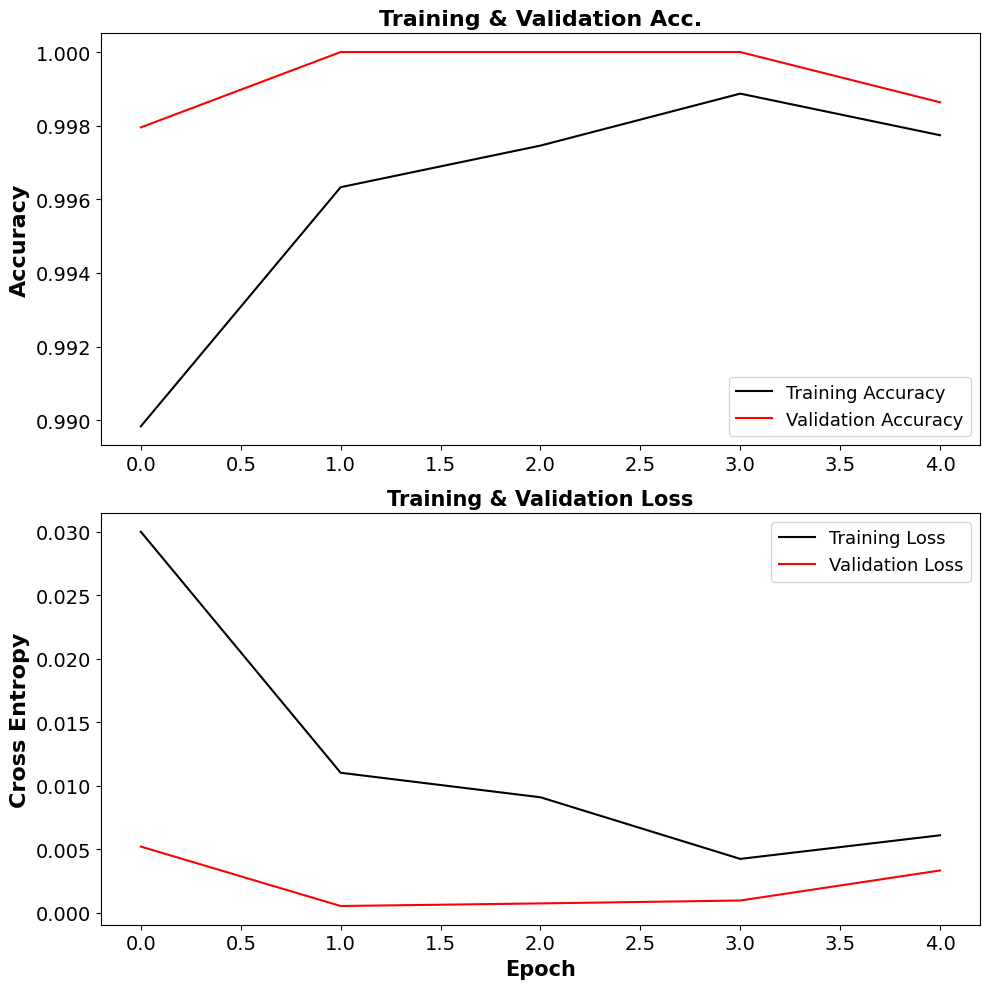

Saved: /content/exp-3-outputs/resnet50_training_curves.png


In [28]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(10, 10))
plt.subplot(2, 1, 1)

plt.plot(acc, label='Training Accuracy', color='black')
plt.plot(val_acc, label='Validation Accuracy', color='red')


plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend(loc='lower right', fontsize=13)
plt.ylabel('Accuracy', fontsize=16, weight='bold')
plt.title('Training & Validation Acc.', fontsize=16, weight='bold')

plt.subplot(2, 1, 2)
plt.plot(loss, label='Training Loss', color='black')
plt.plot(val_loss, label='Validation Loss', color='red')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend(loc='upper right', fontsize=13)
plt.ylabel('Cross Entropy', fontsize=16, weight='bold')
plt.title('Training & Validation Loss', fontsize=15, weight='bold')
plt.xlabel('Epoch', fontsize=15, weight='bold')
plt.tight_layout()
TRAINING_CURVES_PATH = OUTPUT_DIR / 'resnet50_training_curves.png'
plt.savefig(TRAINING_CURVES_PATH, dpi=160, bbox_inches='tight')
plt.show()
print('Saved:', TRAINING_CURVES_PATH)


In [30]:
# Load the checkpoint selected only by validation loss.
best_model = keras.models.load_model(BEST_MODEL_PATH)
assert test_resnet.shuffle is False

test_resnet.reset()
test_metrics = best_model.evaluate(
    test_dataset, steps=len(test_resnet), return_dict=True, verbose=1
)

test_resnet.reset()
test_probabilities = best_model.predict(test_resnet, verbose=1).ravel()
y_true = np.asarray(test_resnet.classes, dtype=int)
y_pred = (test_probabilities >= 0.5).astype(int)

expected_test_samples = len(test_df)
assert len(y_true) == expected_test_samples == 1451
assert test_probabilities.shape == (expected_test_samples,)
assert np.isfinite(test_probabilities).all()
assert ((test_probabilities >= 0.0) & (test_probabilities <= 1.0)).all()

target_names = ['benign', 'adenocarcinoma']
report = classification_report(
    y_true,
    y_pred,
    target_names=target_names,
    output_dict=True,
    zero_division=0,
)
print(classification_report(
    y_true, y_pred, target_names=target_names, digits=4, zero_division=0
))
print('Test metrics:', test_metrics)

46/46 ━━━━━━━━━━━━━━━━━━━━ 15s 234ms/step - accuracy: 0.9986 - loss: 0.0039 - precision: 1.0000 - recall: 0.9973 - roc_auc: 1.0000
46/46 ━━━━━━━━━━━━━━━━━━━━ 15s 258ms/step
                precision    recall  f1-score   support

        benign     0.9971    1.0000    0.9986       697
adenocarcinoma     1.0000    0.9973    0.9987       754

      accuracy                         0.9986      1451
     macro avg     0.9986    0.9987    0.9986      1451
  weighted avg     0.9986    0.9986    0.9986      1451

Test metrics: {'accuracy': 0.9986216425895691, 'loss': 0.003939524758607149, 'precision': 1.0, 'recall': 0.9973474740982056, 'roc_auc': 0.9999905228614807}


In [31]:
def plot_confusion_matrix(cm, classes,
                          normalize=True,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title, weight='bold', fontsize=16)
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, fontsize=14)
    plt.yticks(tick_marks, classes, fontsize=14)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center", fontsize=12, weight='bold',
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label', fontsize=16, weight='bold')
    plt.xlabel('Predicted label', fontsize=16, weight='bold')

Normalized confusion matrix


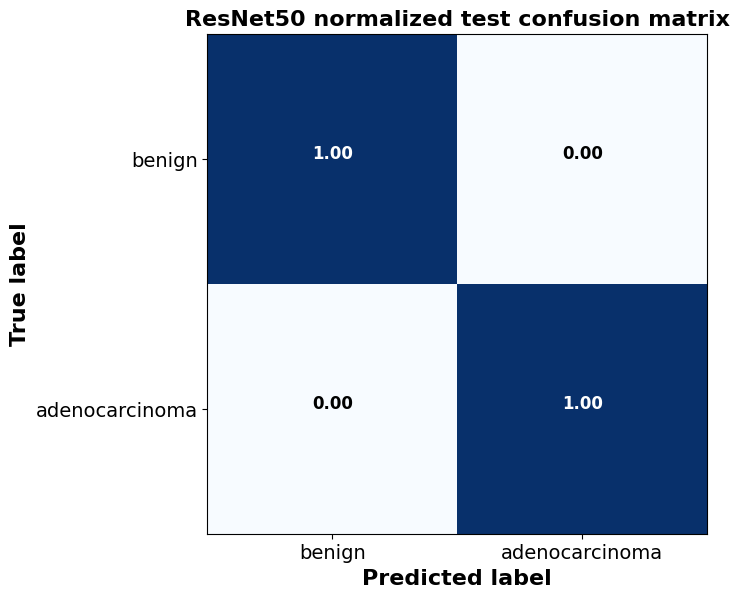

,benign,adenocarcinoma
benign,697,0
adenocarcinoma,2,752


In [32]:
cnf_matrix = confusion_matrix(y_true, y_pred, labels=[0, 1])
assert cnf_matrix.shape == (2, 2)
assert cnf_matrix.sum() == len(y_true) == 1451

CONFUSION_MATRIX_PATH = OUTPUT_DIR / 'resnet50_confusion_matrix.csv'
CONFUSION_MATRIX_NORMALIZED_PATH = OUTPUT_DIR / 'resnet50_confusion_matrix_normalized.csv'
CONFUSION_MATRIX_PLOT_PATH = OUTPUT_DIR / 'resnet50_confusion_matrix.png'

cm_frame = pd.DataFrame(cnf_matrix, index=target_names, columns=target_names)
cm_frame.to_csv(CONFUSION_MATRIX_PATH)
cm_normalized = cnf_matrix / cnf_matrix.sum(axis=1, keepdims=True)
pd.DataFrame(cm_normalized, index=target_names, columns=target_names).to_csv(
    CONFUSION_MATRIX_NORMALIZED_PATH
)

plt.figure(figsize=(7, 7))
plot_confusion_matrix(
    cnf_matrix,
    classes=target_names,
    normalize=True,
    title='ResNet50 normalized test confusion matrix',
)
plt.savefig(CONFUSION_MATRIX_PLOT_PATH, dpi=160, bbox_inches='tight')
plt.show()
display(cm_frame)

In [34]:
METRICS_PATH = OUTPUT_DIR / 'resnet50_test_metrics.json'
REPORT_PATH = OUTPUT_DIR / 'resnet50_classification_report.json'
PREDICTIONS_PATH = OUTPUT_DIR / 'resnet50_test_predictions.csv'

metrics_evidence = {key: float(value) for key, value in test_metrics.items()}
metrics_evidence.update({
    'decision_threshold': 0.5,
    'test_samples': int(len(y_true)),
    'test_groups': int(test_df['group_id'].nunique()),
    'misclassified_images': int(np.sum(y_true != y_pred)),
    'groups_with_any_error': int(
        test_df.loc[y_true != y_pred, 'group_id'].nunique()
    ),
    'best_epoch': int(np.argmin(history.history['val_loss']) + 1),
    'best_validation_loss': float(np.min(history.history['val_loss'])),
})
METRICS_PATH.write_text(json.dumps(metrics_evidence, indent=2), encoding='utf-8')
REPORT_PATH.write_text(json.dumps(report, indent=2), encoding='utf-8')
print('Evidence metrics:', metrics_evidence)

prediction_evidence = test_df[[
    'relative_path', 'class_name', 'label', 'group_id', 'local_cluster_label'
]].copy()
prediction_evidence['adenocarcinoma_probability'] = test_probabilities
prediction_evidence['predicted_label'] = y_pred
prediction_evidence['predicted_class'] = np.where(
    y_pred == 1, 'adenocarcinoma', 'benign'
)
prediction_evidence.to_csv(PREDICTIONS_PATH, index=False)

for artifact_path in [METRICS_PATH, REPORT_PATH, PREDICTIONS_PATH,
                      CONFUSION_MATRIX_PATH, CONFUSION_MATRIX_NORMALIZED_PATH,
                      CONFUSION_MATRIX_PLOT_PATH, TRAINING_CURVES_PATH]:
    assert artifact_path.is_file(), artifact_path
    print('Saved:', artifact_path)

Evidence metrics: {'accuracy': 0.9986216425895691, 'loss': 0.003939524758607149, 'precision': 1.0, 'recall': 0.9973474740982056, 'roc_auc': 0.9999905228614807, 'decision_threshold': 0.5, 'test_samples': 1451, 'test_groups': 77, 'misclassified_images': 2, 'groups_with_any_error': 1, 'best_epoch': 2, 'best_validation_loss': 0.0005319926422089338}
Saved: /content/exp-3-outputs/resnet50_test_metrics.json
Saved: /content/exp-3-outputs/resnet50_classification_report.json
Saved: /content/exp-3-outputs/resnet50_test_predictions.csv
Saved: /content/exp-3-outputs/resnet50_confusion_matrix.csv
Saved: /content/exp-3-outputs/resnet50_confusion_matrix_normalized.csv
Saved: /content/exp-3-outputs/resnet50_confusion_matrix.png
Saved: /content/exp-3-outputs/resnet50_training_curves.png


## Color-only explanatory baseline

This post-hoc baseline tests how separable the same group-aware task is using only 96 global color features: 32 normalized histogram bins for each RGB channel. It uses the existing train/test partition, so complete `group_id` families remain isolated. A high score indicates that global color is strongly predictive in LC25000; it is not external or clinical validation.

In [38]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

HISTOGRAM_BINS = 32
HISTOGRAM_METRICS_PATH = OUTPUT_DIR / 'color_histogram_baseline_metrics.json'
HISTOGRAM_PREDICTIONS_PATH = OUTPUT_DIR / 'color_histogram_test_predictions.csv'

def rgb_histogram(filepath):
    """Return normalized 32-bin histograms for the three RGB channels."""
    image = keras.utils.load_img(
        filepath,
        color_mode='rgb',
        target_size=(IMG_SIZE, IMG_SIZE),
        interpolation='nearest',
    )
    pixels = np.asarray(image, dtype=np.uint8)
    channel_histograms = [
        np.histogram(
            pixels[..., channel],
            bins=HISTOGRAM_BINS,
            range=(0, 256),
        )[0]
        for channel in range(3)
    ]
    signature = np.concatenate(channel_histograms).astype(np.float32)
    return signature / (IMG_SIZE * IMG_SIZE)

histogram_signatures = np.empty((len(grouped_image_index), 96), dtype=np.float32)
for position, filepath in enumerate(grouped_image_index['filepath']):
    histogram_signatures[position] = rgb_histogram(filepath)
    if (position + 1) % 1000 == 0:
        print(f'Calculated {position + 1:,}/10,000 histograms')

assert histogram_signatures.shape == (10_000, 96)
assert np.isfinite(histogram_signatures).all()
signature_position = {
    relative_path: position
    for position, relative_path in enumerate(grouped_image_index['relative_path'])
}

def signatures_for(frame):
    """Select histogram signatures in the exact row order of a partition."""
    positions = [signature_position[path] for path in frame['relative_path']]
    return histogram_signatures[positions]

histogram_baseline = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=2000, random_state=SEED),
)
histogram_baseline.fit(signatures_for(train_df), train_df['label'])
histogram_predictions = histogram_baseline.predict(signatures_for(test_df))
histogram_probabilities = histogram_baseline.predict_proba(
    signatures_for(test_df)
)[:, 1]
histogram_accuracy = accuracy_score(test_df['label'], histogram_predictions)
histogram_report = classification_report(
    test_df['label'],
    histogram_predictions,
    target_names=['benign', 'adenocarcinoma'],
    output_dict=True,
    zero_division=0,
)
histogram_error_mask = test_df['label'].to_numpy() != histogram_predictions
histogram_metrics = {
    'experiment_id': 'exp-3-color-histogram-baseline',
    'features': '32 normalized bins per RGB channel',
    'feature_count': 96,
    'classifier': 'StandardScaler + LogisticRegression',
    'split_manifest': 'group_split_manifest.csv',
    'test_accuracy': float(histogram_accuracy),
    'test_samples': int(len(test_df)),
    'test_groups': int(test_df['group_id'].nunique()),
    'misclassified_images': int(histogram_error_mask.sum()),
    'groups_with_any_error': int(
        test_df.loc[histogram_error_mask, 'group_id'].nunique()
    ),
    'resnet50_test_accuracy': float(test_metrics['accuracy']),
    'limitation': (
        'A high score shows that global color is predictive in this internal dataset; '
        'it is not patient-level or external clinical validation.'
    ),
}
HISTOGRAM_METRICS_PATH.write_text(
    json.dumps({**histogram_metrics, 'classification_report': histogram_report}, indent=2),
    encoding='utf-8',
)
histogram_prediction_evidence = test_df[[
    'relative_path', 'class_name', 'label', 'group_id', 'local_cluster_label'
]].copy()
histogram_prediction_evidence['adenocarcinoma_probability'] = histogram_probabilities
histogram_prediction_evidence['predicted_label'] = histogram_predictions
histogram_prediction_evidence.to_csv(HISTOGRAM_PREDICTIONS_PATH, index=False)

print(f'RGB-histogram test accuracy: {histogram_accuracy:.4f}')
print(f'ResNet50 test accuracy:      {test_metrics["accuracy"]:.4f}')
print(classification_report(
    test_df['label'],
    histogram_predictions,
    target_names=['benign', 'adenocarcinoma'],
    digits=4,
    zero_division=0,
))
print('Saved:', HISTOGRAM_METRICS_PATH)
print('Saved:', HISTOGRAM_PREDICTIONS_PATH)

Calculated 1,000/10,000 histograms
Calculated 2,000/10,000 histograms
Calculated 3,000/10,000 histograms
Calculated 4,000/10,000 histograms
Calculated 5,000/10,000 histograms
Calculated 6,000/10,000 histograms
Calculated 7,000/10,000 histograms
Calculated 8,000/10,000 histograms
Calculated 9,000/10,000 histograms
Calculated 10,000/10,000 histograms
RGB-histogram test accuracy: 0.9325
ResNet50 test accuracy:      0.9986
                precision    recall  f1-score   support

        benign     0.8925    0.9770    0.9329       697
adenocarcinoma     0.9767    0.8912    0.9320       754

      accuracy                         0.9325      1451
     macro avg     0.9346    0.9341    0.9325      1451
  weighted avg     0.9363    0.9325    0.9324      1451

Saved: /content/exp-3-outputs/color_histogram_baseline_metrics.json
Saved: /content/exp-3-outputs/color_histogram_test_predictions.csv


In [41]:
import hashlib
import zipfile

def sha256_file(path, chunk_size=1024 * 1024):
    digest = hashlib.sha256()
    with Path(path).open('rb') as handle:
        for chunk in iter(lambda: handle.read(chunk_size), b''):
            digest.update(chunk)
    return digest.hexdigest()

# Preserve the exact group-aware assignment used by this run.
GROUP_SPLIT_MANIFEST_PATH = OUTPUT_DIR / 'group_split_manifest.csv'
GROUP_SPLIT_METADATA_PATH = OUTPUT_DIR / 'group_split_metadata.json'
group_split_manifest = assigned_images[[
    'split', 'relative_path', 'label', 'class_name', 'stem',
    'official_label', 'local_cluster_label', 'group_id',
]].sort_values(['split', 'label', 'relative_path']).reset_index(drop=True)
assert len(group_split_manifest) == 10_000
assert group_split_manifest['relative_path'].is_unique
assert group_split_manifest.groupby('group_id')['split'].nunique().eq(1).all()
group_split_manifest.to_csv(GROUP_SPLIT_MANIFEST_PATH, index=False)

group_split_metadata = {
    'schema_version': 1,
    'experiment_id': 'exp-3',
    'dataset_id': DATASET_ID,
    'groups_source_url': GROUPS_URL,
    'task': 'binary_colon_classification',
    'split_method': 'two-stage GroupShuffleSplit within each class',
    'seed': SEED,
    'requested_fractions': {
        'train': TRAIN_FRACTION,
        'validation': VALIDATION_FRACTION,
        'test': TEST_FRACTION,
    },
    'actual_image_fractions': actual_fractions,
    'image_counts': {name: len(frame) for name, frame in partitions.items()},
    'group_counts': {
        name: int(frame['group_id'].nunique())
        for name, frame in partitions.items()
    },
    'total_images': int(len(group_split_manifest)),
    'total_groups': int(group_split_manifest['group_id'].nunique()),
    'group_overlap': 0,
    'class_mapping': {'benign': 0, 'adenocarcinoma': 1},
    'limitation': (
        'Group-aware tile evaluation is not patient-level or external-cohort validation.'
    ),
}
GROUP_SPLIT_METADATA_PATH.write_text(
    json.dumps(group_split_metadata, indent=2), encoding='utf-8'
)

assert BEST_MODEL_PATH.is_file()
model_sha256 = sha256_file(BEST_MODEL_PATH)
MODEL_MANIFEST_PATH = OUTPUT_DIR / 'resnet50_model_manifest.json'
model_manifest = {
    'model_id': 'resnet50-binary-colon-group-aware',
    'experiment_id': 'exp-3',
    'artifact': BEST_MODEL_PATH.name,
    'format': 'keras_v3',
    'sha256': model_sha256,
    'size_bytes': BEST_MODEL_PATH.stat().st_size,
    'tensorflow_version': tf.__version__,
    'keras_version': keras.__version__,
    'input_shape': [224, 224, 3],
    'preprocessing': 'keras.applications.resnet50.preprocess_input',
    'class_mapping': {'benign': 0, 'adenocarcinoma': 1},
    'output': 'adenocarcinoma_probability',
    'decision_threshold': 0.5,
    'best_epoch': int(np.argmin(history.history['val_loss']) + 1),
    'selection_metric': 'val_loss',
    'split_manifest': GROUP_SPLIT_MANIFEST_PATH.name,
}
MODEL_MANIFEST_PATH.write_text(
    json.dumps(model_manifest, indent=2), encoding='utf-8'
)

EVIDENCE_ARCHIVE_PATH = Path('/content/resnet50-exp-3-evidence.zip')
with zipfile.ZipFile(EVIDENCE_ARCHIVE_PATH, 'w', zipfile.ZIP_DEFLATED) as archive:
    for artifact_path in sorted(OUTPUT_DIR.iterdir()):
        if artifact_path.is_file() and artifact_path != BEST_MODEL_PATH:
            archive.write(artifact_path, arcname=artifact_path.name)

print('Group split manifest:', GROUP_SPLIT_MANIFEST_PATH)
print('Group split metadata:', GROUP_SPLIT_METADATA_PATH)
print('Best model:', BEST_MODEL_PATH)
print('SHA-256:', model_sha256)
print('Evidence archive:', EVIDENCE_ARCHIVE_PATH)

Group split manifest: /content/exp-3-outputs/group_split_manifest.csv
Group split metadata: /content/exp-3-outputs/group_split_metadata.json
Best model: /content/exp-3-outputs/resnet50_binary_best.keras
SHA-256: cdcd06a7d5cde685bc70eeb391b93b5393806ae952379746c195ca0f66e23691
Evidence archive: /content/resnet50-exp-3-evidence.zip


In [42]:
from google.colab import files

# Download both before disconnecting the Colab runtime.
files.download(str(BEST_MODEL_PATH))
files.download(str(EVIDENCE_ARCHIVE_PATH))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [40]:
# The compact evidence archive and model were downloaded above.
# A second ZIP of the output directory would duplicate the large model.
print('Experiment 3 preservation complete.')


Experiment 3 preservation complete.
